In [50]:
from matplotlib.colors import hsv_to_rgb
import random
import numpy as np
import numpy.typing as npt
# yes i type annotate in python im just built different like that
from typing import *
import math
import matplotlib.pyplot as plt

In [ ]:
class Agent:
    def __init__(self, prob_init_0: float = 0, matrix_00: float = 0, matrix_10: float = 0):
       # the variable naming is basically just matrix_00 = matrix[0,0]
       # i tried to match the code to the way its defined mathematically in the report
       # its sorta weird looking as python code but its pretty much a 1:1 replication of the formulas in the report
       # so go read the report if anything seems weird
       self.init_state = np.array([prob_init_0, 1 - prob_init_0])
       self.matrix = np.array([
                [matrix_00, 1-matrix_00],
                [matrix_10, 1-matrix_10]])
    
    def randomize(self):
        """uniformly randomizes all strategy params"""
        # this ones not used
        prob_init_0 = random.uniform(0,1)
        matrix_00 = random.uniform(0,1)
        matrix_10 = random.uniform(0,1)

        self.init_state = np.array([prob_init_0, 1 - prob_init_0])
        self.matrix = np.array([
                [matrix_00, 1-matrix_00],
                [matrix_10, 1-matrix_10]])
    
    def randomize_norm(self, avg, sd=1):
        """randomizes params according to normal distribution"""
        # this ones useful though
        # not mentioned in report but you have to clip everything 0 to 1 otherwise you have negative probabilities
        prob_init_0 = np.clip(random.normalvariate(avg, sd), 0, 1)
        matrix_00 = np.clip(random.normalvariate(avg, sd), 0, 1)
        matrix_10 = np.clip(random.normalvariate(avg, sd), 0, 1)

        self.init_state = np.array([prob_init_0, 1 - prob_init_0])
        self.matrix = np.array([
                [matrix_00, 1-matrix_00],
                [matrix_10, 1-matrix_10]])
    
    def clone(self):
        """agents must be cloned before being updated otherwise the history graph is useless cause its just one agent getting changed a bajillion times"""
        return Agent(self.init_state[0], self.matrix[0,0], self.matrix[1,0])
    
    def __str__(self):
        # i made this for debugging its cool try using it
        return f"start: {self.init_state[0]:.2f} | 0->0: {self.matrix[0,0]:.2f} | 1->0: {self.matrix[1,0]:.2f}"

class Population:
    """This is basically just a collection of agents"""
    def __init__(self, n_agents: int, randomize = True):
        self.agents: List[Agent] = []
        for i in range(n_agents):
            self.agents.append(Agent())
        if randomize:
            self.randomize()

    def randomize(self):
        for a in self.agents:
            a.randomize()
    
    def randomize_norm(self, avg, sd=1):
        for a in self.agents:
            a.randomize_norm(avg, sd)
    


def anneal_population(population: Population, reward_fn, step_size: float, temp: float) -> Population:
    """
        Run one iteration of simulated annealing, then return a new population with the result
        this doesn't modify the original population (important for graphing!)
        reward_fn: Agent, List[Agent] -> float
    """
    new_pop = Population(n_agents=0)
    for i, agent in enumerate(population.agents):
        other_agents = [x for x in population.agents if x != agent]
        
        # Generate a modified candidate agent
        init_0 = np.clip(agent.init_state[0] + random.uniform(-step_size, step_size), a_min=0, a_max=1)
        m_00 = np.clip(agent.matrix[0,0] + random.uniform(-step_size, step_size), a_min=0, a_max=1)
        m_10 = np.clip(agent.matrix[1,0] + random.uniform(-step_size, step_size), a_min=0, a_max=1)

        new_agent = Agent(init_0, m_00, m_10)

        old_reward = reward_fn(agent, other_agents)
        new_reward = reward_fn(new_agent, other_agents)

        # Yeah its metropolis criterion time
        prob_accept = 0

        if new_reward > old_reward:
            prob_accept = 1
        else:
            prob_accept = np.e ** ((new_reward - old_reward) / temp)
        
        if random.uniform(0,1) < prob_accept:
            new_pop.agents.append(new_agent)
        else:
            new_pop.agents.append(agent.clone())

    return new_pop


def avg_reward_fn(agent: Agent, other_agents: List[Agent], reward_matrix: npt.NDArray[np.float64], sample_ratio: float = 1, rounds: int =10):
    """returns the expected average reward obtained by an agent competing against a set of other agents
    sample_ratio can be set to < 1 to have the agent compete against a smaller portion of the population to reduce runtime"""
    total_reward = 0
    random.shuffle(other_agents)
    n_sample = int(sample_ratio * len(other_agents))
    for opp in other_agents[:n_sample]:
        e_state, e_reward = simulate_game(agent, opp, reward_matrix, rounds)
        total_reward += e_reward[-1,0]
    return total_reward / len(other_agents)

    
def simulate_game(agent_a: Agent, agent_b: Agent, reward_matrix: npt.NDArray[np.float64], rounds: int) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    """
        Runs the prisoner's dilemma game for agents A and B
        Returns a tuple containing (expected state, expected_reward)
        expected_state[t,x] = prob agent x cooperates at round t
        expected_reward[t,x] = reward for agent x at round t
    """
    A = agent_a.init_state
    B = agent_b.init_state
    
    A_reward = 0
    B_reward = 0

    state_history = np.zeros(shape=(rounds,2))
    reward_history = np.zeros(shape=(rounds,2))

    for r in range(rounds):
        # i wrote out the reasoning for all of the matrix multiplications on a piece of paper
        # when i reread it didnt make any sense to me but the code actually works somehow

        # S is the combined state of A and B (i called it X in the paper in case u were wondering. S is a better name but i used S for a different variable in the paper)
        # S[i,j] = prob A does i and B does j
        S = np.matmul(np.expand_dims(A,1), np.expand_dims(B,1).T)

        # update the cumulative reward for each agent
        A_reward += np.sum(reward_matrix[:,:,0] * S)
        B_reward += np.sum(reward_matrix[:,:,1] * S)

        # keep track of the states and rewards history
        state_history[r,:] = [A[0],B[0]]
        reward_history[r,:] = [A_reward, B_reward]

        # update the states of A and B
        An = np.matmul(agent_a.matrix.T, B)
        Bn = np.matmul(agent_b.matrix.T, A)

        A = An
        B = Bn
    
    return (state_history, reward_history)



In [157]:
def plot_population_avg_strategy(history: List[Population]):
    """Plots the average strategy values of a population over time"""
    t = np.arange(len(history))
    matrix_00 = []
    matrix_10 = []
    init_0 = []
    for pop in history:
        # matrices shape = (n_agents, 2, 2)
        matrices = np.array([x.matrix for x in pop.agents])
        avg_matrix = np.mean(matrices,axis=0)

        inits = np.array([x.init_state for x in pop.agents])
        avg_init = np.mean(inits,axis=0)

        # this is: first round / after coop / after defect
        matrix_00.append(avg_matrix[0,0])
        matrix_10.append(avg_matrix[1,0])
        init_0.append(avg_init[0])
    
    plt.ylim(-0.01, 1.01)
    plt.xlabel("Iterations")
    plt.ylabel("Probability")
    plt.plot(t, init_0, linestyle='dashed', color='green')
    plt.plot(t, matrix_00, color='red')
    plt.plot(t, matrix_10, color='blue')
    
    plt.legend(["Cooperate at Start", "Cooperate after Opponent Cooperates", "Cooperate after Opponent Defects"])


In [171]:
# this isnt used in the report but its really cool
def plot_population_individual_strategy(history: List[Population], figsize, title):
    """Create 3 different plots.
    1. First round action
    2. Response to cooperate
    3. Response to defect"""

    n_agents = len(history[0].agents)

    agent_history = np.zeros(shape=(len(history),n_agents,3))
    for pop_idx, pop in enumerate(history):
        for a_idx, a in enumerate(pop.agents):
            init = a.init_state[0]
            m00 = a.matrix[0,0]
            m10 = a.matrix[1,0]
            agent_history[pop_idx,a_idx] = [init,m00,m10]
    fig = plt.figure(figsize=figsize)
    titles = ["Cooperate at Start", "Cooperate after Opponent Cooperates", "Cooperate after Opponent Defects"]
    for i in range (3):
        plt.subplot(1, 3, i+1)
        plt.title(titles[i])
        plt.xlabel("Iterations")
        plt.ylabel("Probability")
        plt.ylim(-0.01, 1.01)
        x = np.arange(len(history))
        for agent_idx in range(n_agents):
            c = hsv_to_rgb((agent_idx/n_agents,
                            0.9, 
                            0.9))
            c = (c[0], c[1], c[2], 0.8)
            plt.plot(x, agent_history[:,agent_idx,i], color=c)
    plt.suptitle(title)
    fig.tight_layout()

In [137]:
# this also isnt used in the report but its really cool
def plot_population_phase_plane(history: List[Population]):
    """Plots the average markov chain values of a population over time"""
    t = np.arange(len(history))

    plt.title("Population Markov Chains over Time")
    plt.xlabel("Cooperate after Opponent Cooperates")
    plt.ylabel("Cooperate after Opponent Defects")
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.01, 1.01)

    for agent_idx in range(len(history[0].agents)):
        agent_history = [pop.agents[agent_idx] for pop in history]
        m00_history = [a.matrix[0,0] for a in agent_history]
        m10_history = [a.matrix[1,0] for a in agent_history]
        c = hsv_to_rgb((agent_idx/(len(history[0].agents)),0.7,0.7))
        c = (c[0], c[1], c[2], 0.7)
        plt.plot(m00_history[0], m10_history[0], 'o', color = c)
        for i in range(len(m00_history)-1):
            c = hsv_to_rgb((agent_idx/(len(history[0].agents)),0.9, 0.9 - (i/len(m00_history))*0.3))
            c = (c[0], c[1], c[2], 0.7)
            plt.arrow(m00_history[i], 
                      m10_history[i], 
                      m00_history[i+1] - m00_history[i],
                      m10_history[i+1] - m10_history[i],
                      color = c,
                      head_width=0.01)
    

In [156]:
reward_matrix = np.array([
        [[2,2],[0,3]],
        [[3,0],[1,1]]])
reward_fn = lambda agent, others: avg_reward_fn(agent, others, reward_matrix, sample_ratio=1, rounds = 10)
anneal_iters = 150
temp = 1
temp_decay = 0.8

In [166]:
record = []

C:\Users\aaron\AppData\Local\Temp\ipykernel_26940\2336975201.py:82: RuntimeWarning: overflow encountered in double_scalars
  prob_accept = np.e ** ((new_reward - old_reward) / temp)


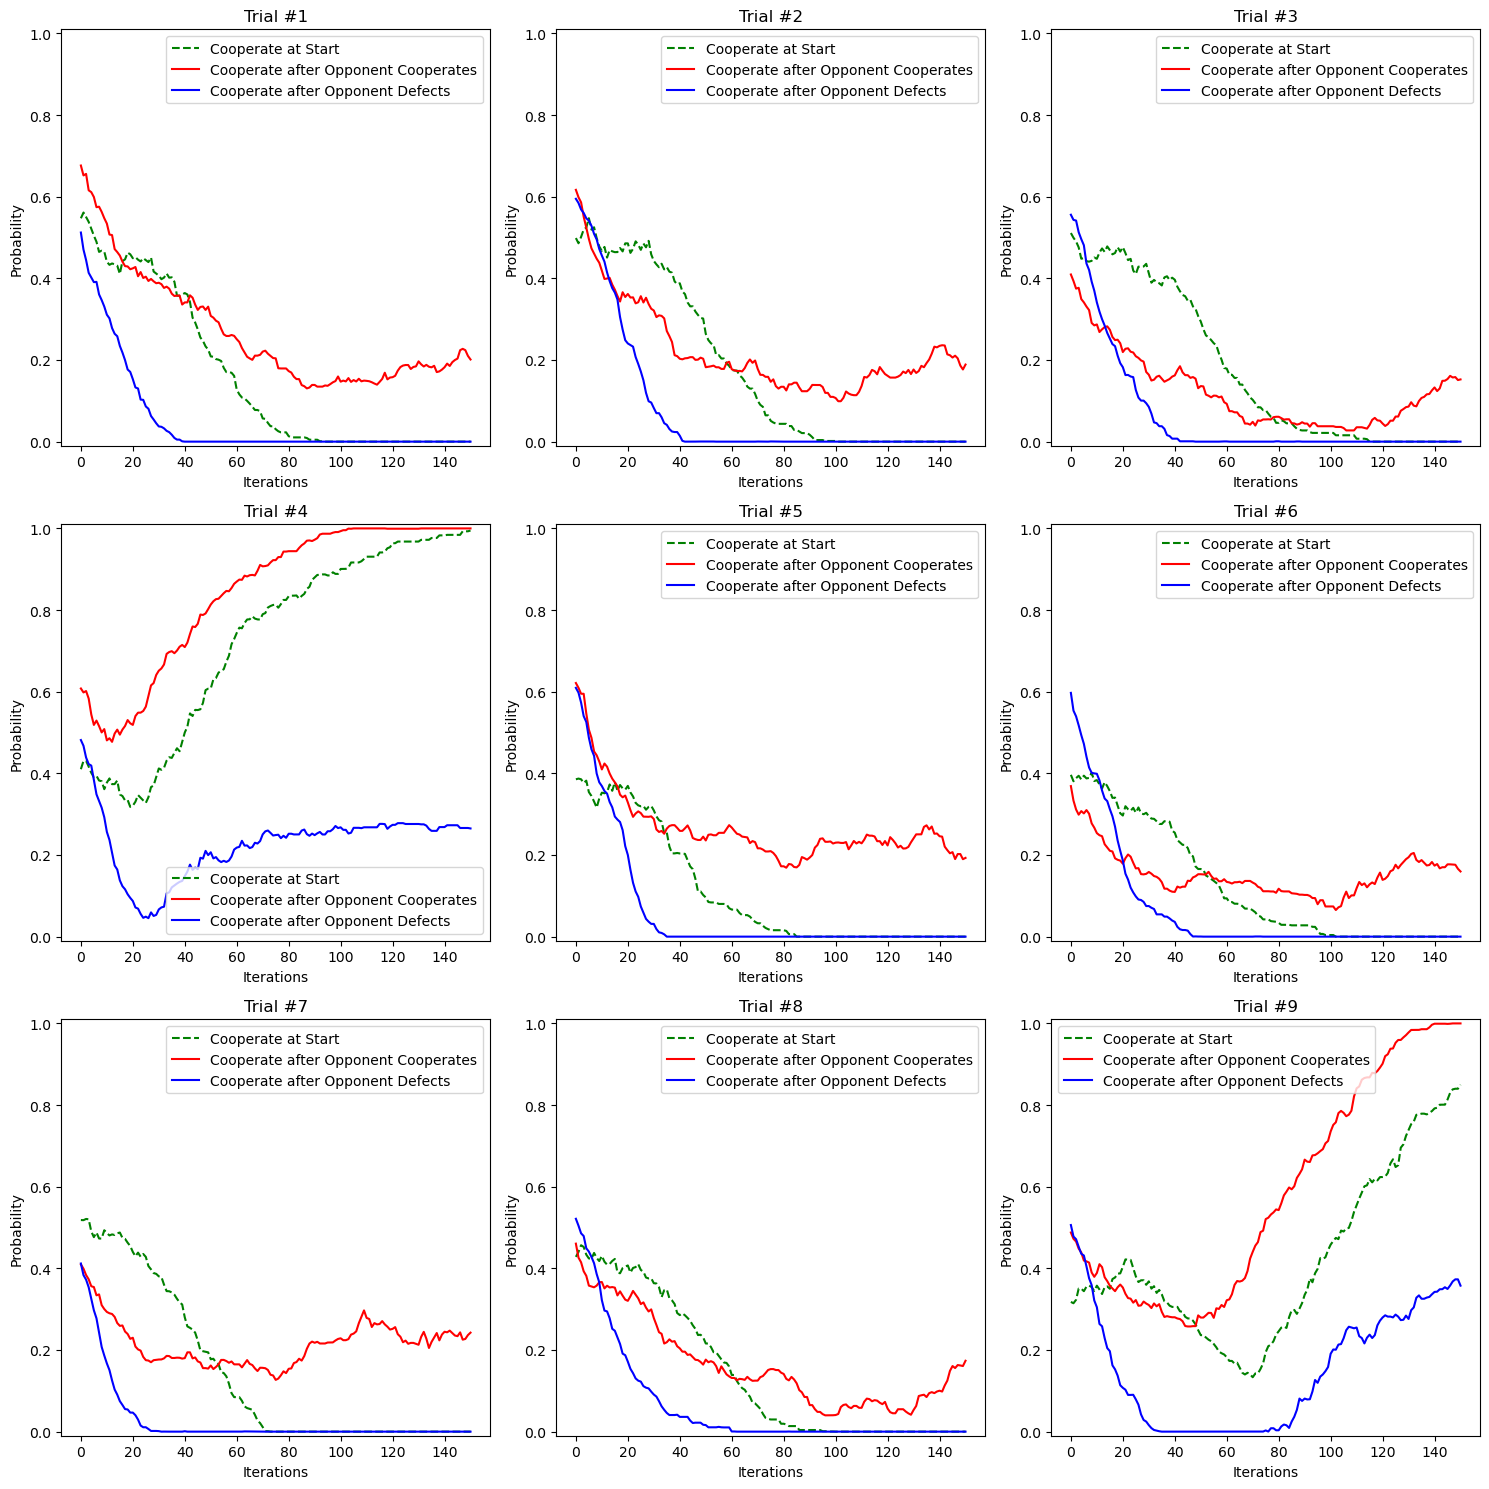

In [167]:
# to make this run fast just change width = height = 1
# this will make it do 1 trial instead of 9
# same applies for all other graphs below

width = 3
height = 3
fig = plt.figure(figsize=(15,15))

for gridx in range(width):
    for gridy in range(height):
        trial = gridy * height + gridx + 1
        plt.subplot(height, width, trial)
        pop0 = Population(n_agents = 10)
        pop0.randomize_norm(0.5,0.25)
        history = [pop0]

        for i in range(anneal_iters):
            temp = temp * temp_decay
            new_pop = anneal_population(history[-1], reward_fn, step_size=0.1, temp=temp)
            history.append(new_pop)
        plt.title(f"Trial #{trial}")
        plot_population_avg_strategy(history)
        record.append(history)
fig.tight_layout()
plt.show()

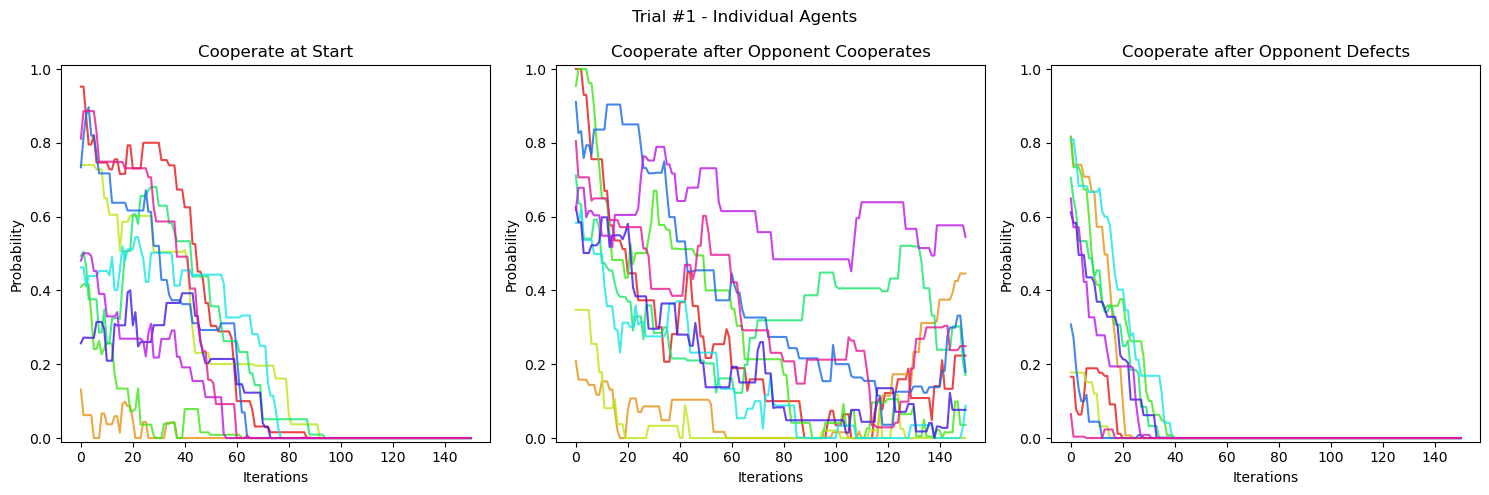

In [173]:
plot_population_individual_strategy(record[0], figsize=(15,5), title="Trial #1 - Individual Agents")
plt.show()

C:\Users\aaron\AppData\Local\Temp\ipykernel_26940\2336975201.py:82: RuntimeWarning: overflow encountered in double_scalars
  prob_accept = np.e ** ((new_reward - old_reward) / temp)


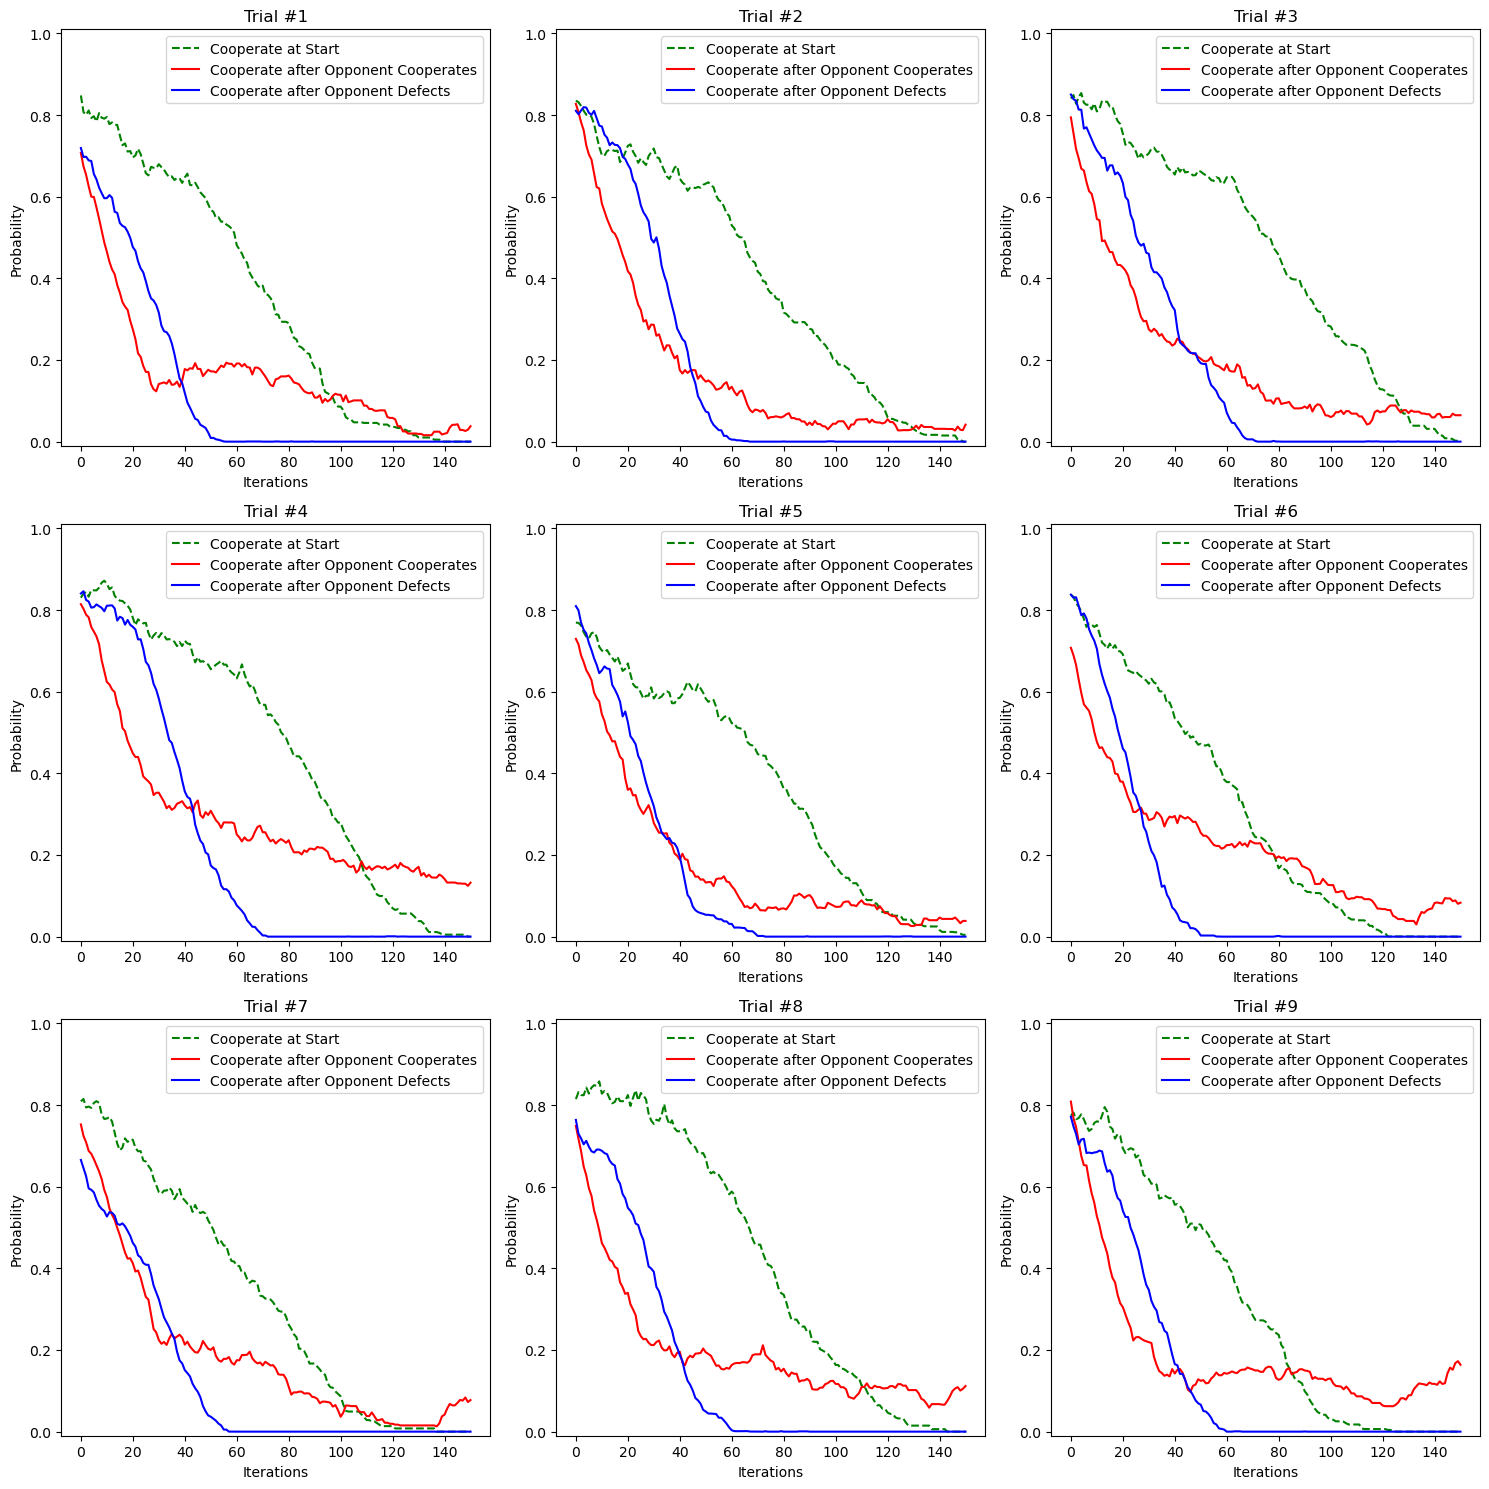

In [174]:
width = 3
height = 3
fig = plt.figure(figsize=(15,15))
for gridx in range(width):
    for gridy in range(height):
        trial = gridy * height + gridx + 1
        plt.subplot(height, width, trial)
        pop0 = Population(n_agents = 10)
        pop0.randomize_norm(0.8,0.25)
        history = [pop0]

        for i in range(anneal_iters):
            temp = temp * temp_decay
            new_pop = anneal_population(history[-1], reward_fn, step_size=0.1, temp=temp)
            history.append(new_pop)
        plt.title(f"Trial #{trial}")
        plot_population_avg_strategy(history)
        record.append(history)
fig.tight_layout()
plt.show()



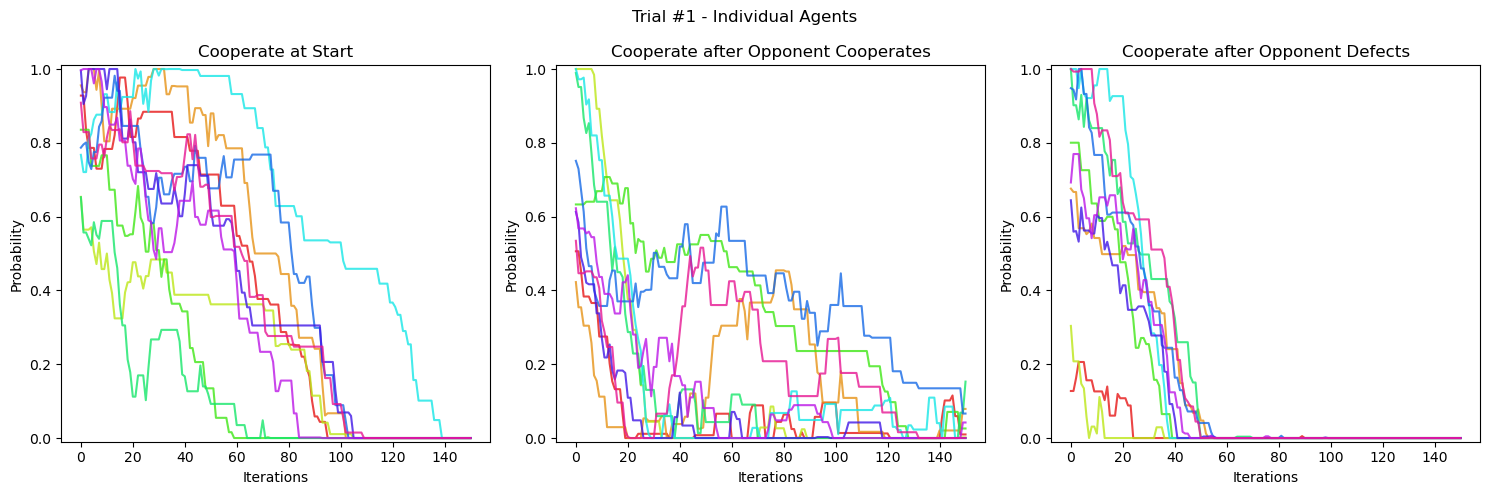

In [176]:
plot_population_individual_strategy(record[0], figsize=(15,5), title="Trial #1 - Individual Agents")
plt.show()

C:\Users\aaron\AppData\Local\Temp\ipykernel_26940\2336975201.py:82: RuntimeWarning: overflow encountered in double_scalars
  prob_accept = np.e ** ((new_reward - old_reward) / temp)


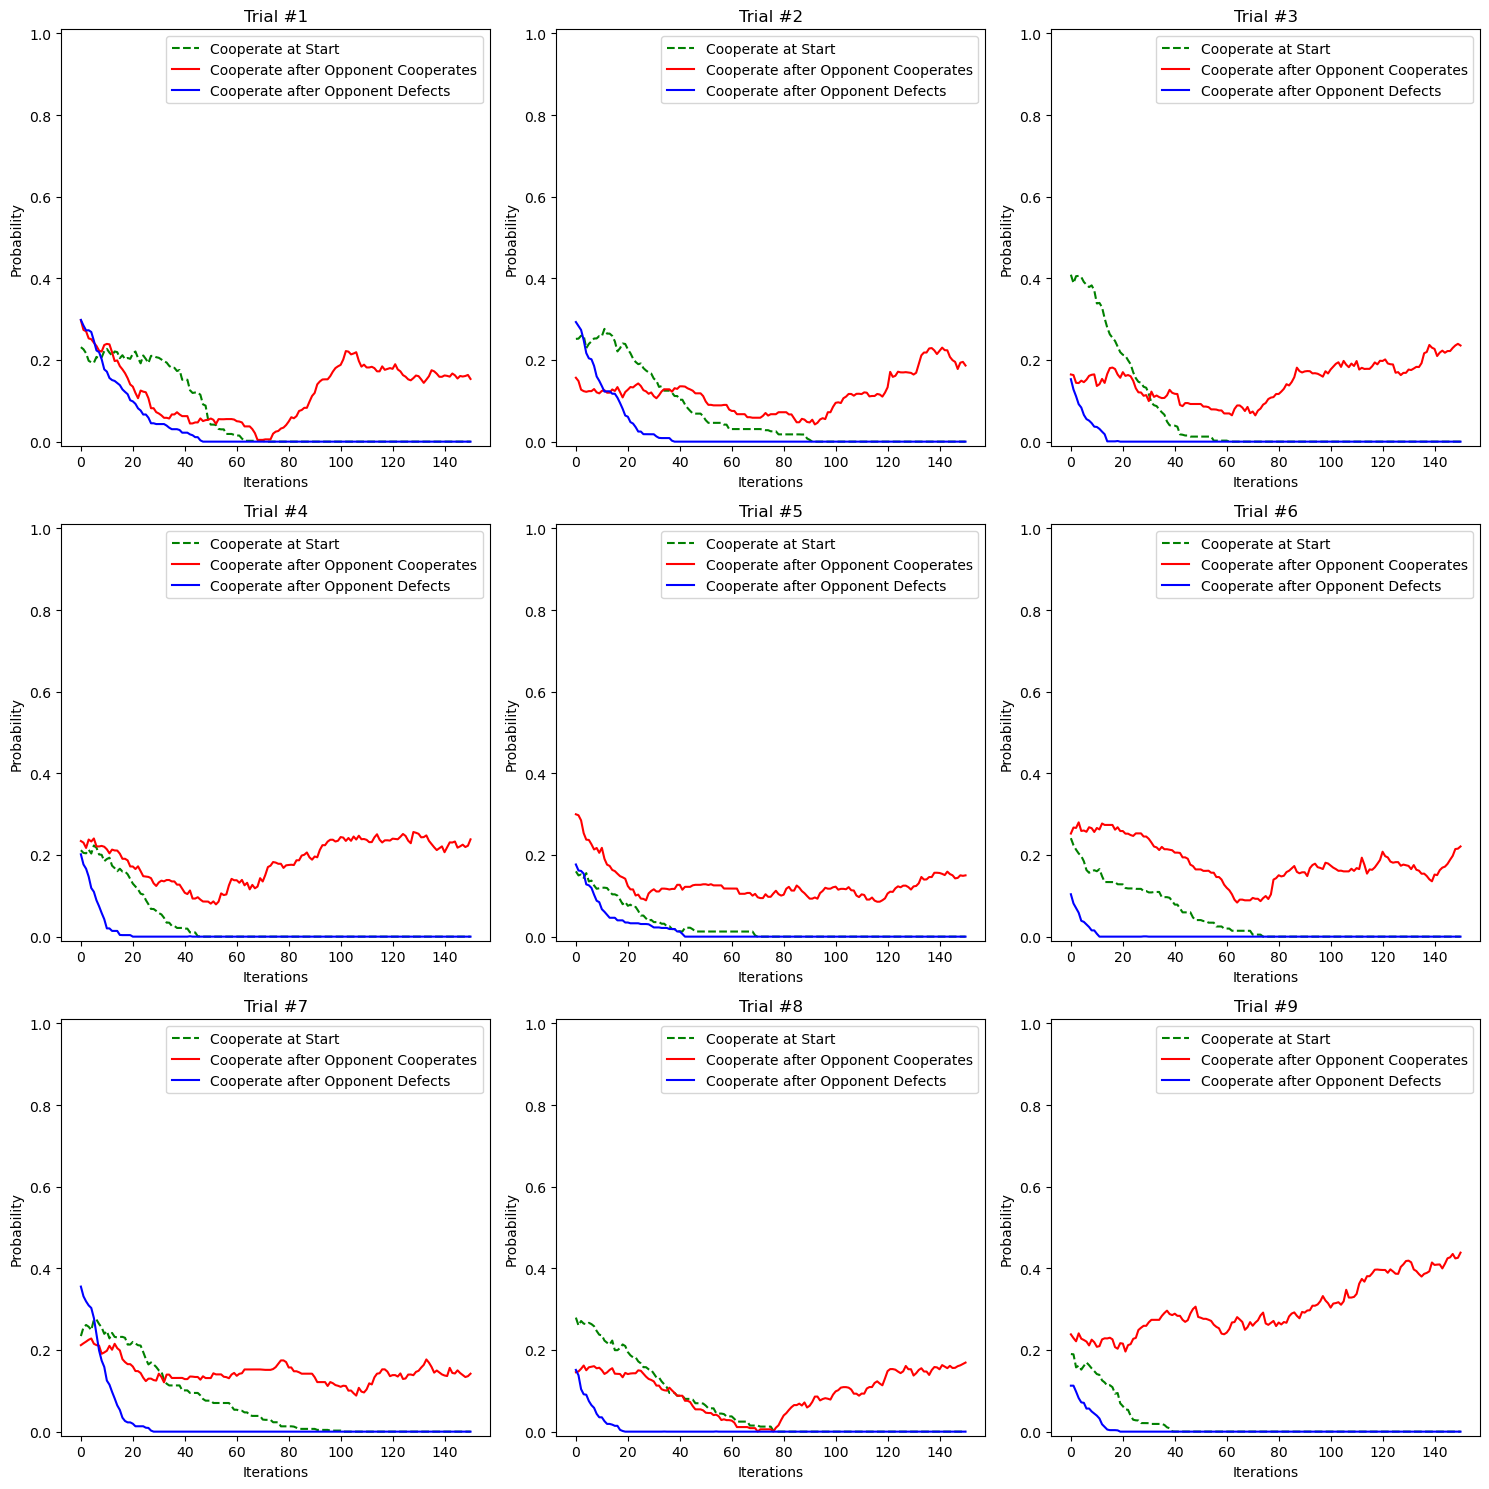

In [177]:
width = 3
height = 3
fig = plt.figure(figsize=(15,15))
record = []
for gridx in range(width):
    for gridy in range(height):
        trial = gridy * height + gridx + 1
        plt.subplot(height, width, trial)
        pop0 = Population(n_agents = 10)
        pop0.randomize_norm(0.2,0.25)
        history = [pop0]

        for i in range(anneal_iters):
            temp = temp * temp_decay
            new_pop = anneal_population(history[-1], reward_fn, step_size=0.1, temp=temp)
            history.append(new_pop)
        plt.title(f"Trial #{trial}")
        plot_population_avg_strategy(history)
        record.append(history)
fig.tight_layout()
plt.show()



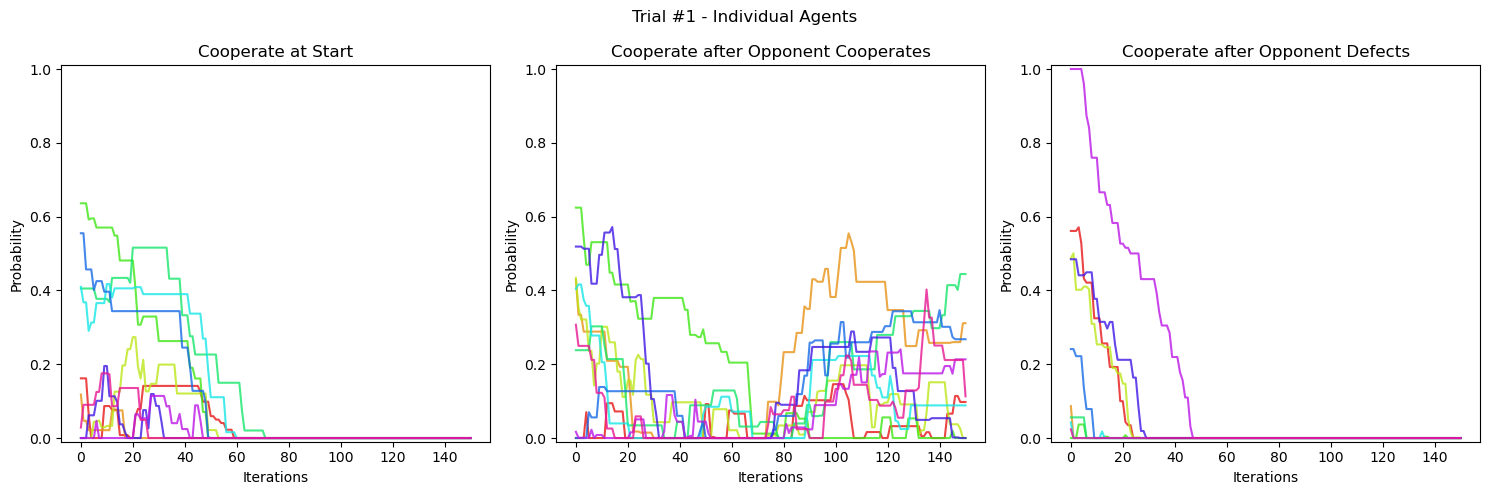

In [178]:
plot_population_individual_strategy(record[0], figsize=(15,5), title="Trial #1 - Individual Agents")
plt.show()

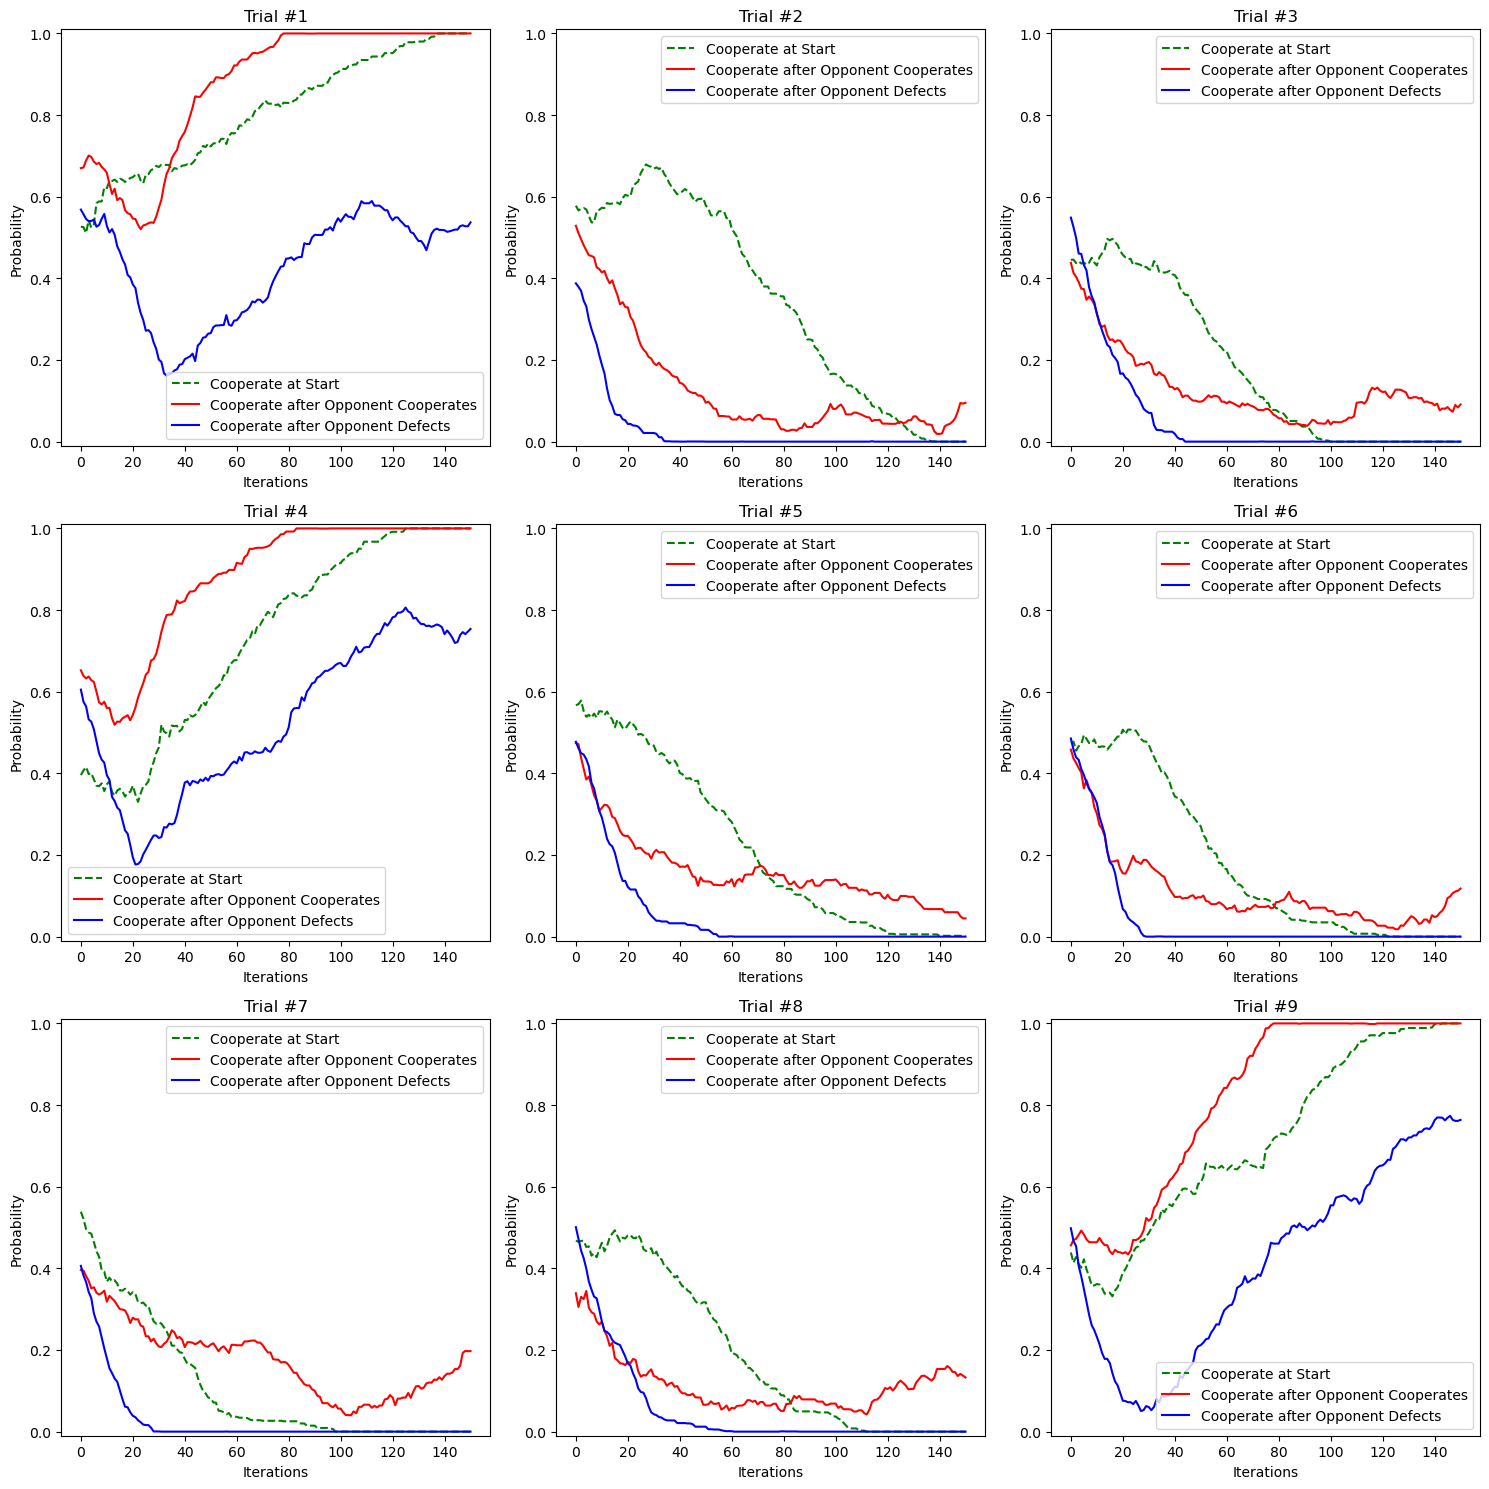

In [180]:
reward_matrix = np.array([
        [[2.75,2.75],[0,3]],
        [[3,0],[1,1]]])
reward_fn = lambda agent, others: avg_reward_fn(agent, others, reward_matrix, sample_ratio=1, rounds = 10)
anneal_iters = 150
temp = 1
temp_decay = 0.8

width = 3
height = 3
fig = plt.figure(figsize=(15,15))
record = []
for gridx in range(width):
    for gridy in range(height):
        trial = gridy * height + gridx + 1
        plt.subplot(height, width, trial)
        pop0 = Population(n_agents = 10)
        pop0.randomize_norm(0.5,0.25)
        history = [pop0]

        for i in range(anneal_iters):
            temp = temp * temp_decay
            new_pop = anneal_population(history[-1], reward_fn, step_size=0.1, temp=temp)
            history.append(new_pop)
        plt.title(f"Trial #{trial}")
        plot_population_avg_strategy(history)
        record.append(history)
fig.tight_layout()
plt.show()

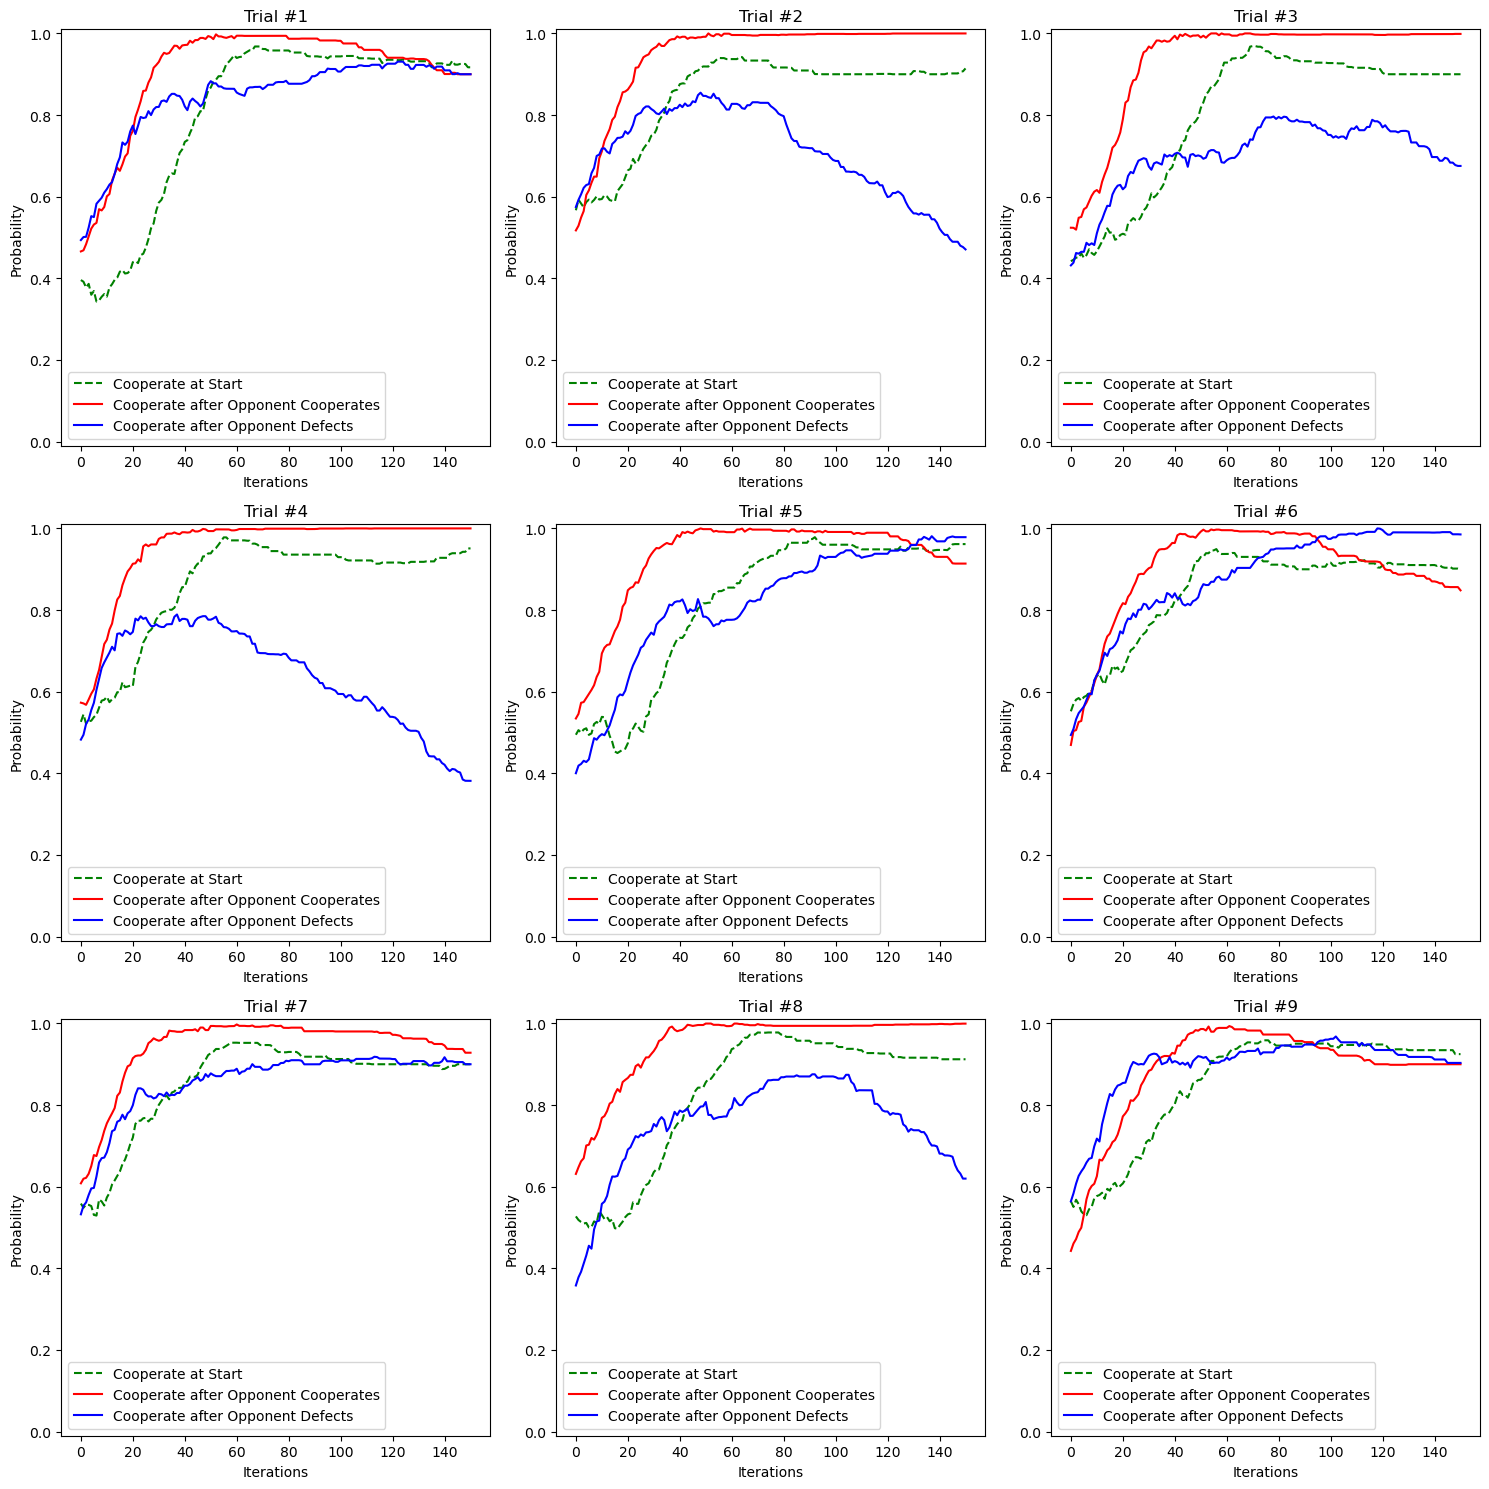

In [183]:
reward_matrix = np.array([
        [[2,2],[0,3]],
        [[3,0],[-100,-100]]])
reward_fn = lambda agent, others: avg_reward_fn(agent, others, reward_matrix, sample_ratio=1, rounds = 10)
anneal_iters = 150
temp = 1
temp_decay = 0.8

width = 3
height = 3
fig = plt.figure(figsize=(15,15))
record = []
for gridx in range(width):
    for gridy in range(height):
        trial = gridy * height + gridx + 1
        plt.subplot(height, width, trial)
        pop0 = Population(n_agents = 10)
        pop0.randomize_norm(0.5,0.25)
        history = [pop0]

        for i in range(anneal_iters):
            temp = temp * temp_decay
            new_pop = anneal_population(history[-1], reward_fn, step_size=0.1, temp=temp)
            history.append(new_pop)
        plt.title(f"Trial #{trial}")
        plot_population_avg_strategy(history)
        record.append(history)
fig.tight_layout()
plt.show()